# Import

In [ ]:
!pip install split-folders

In [ ]:
from google.colab import files
import os
import matplotlib.pyplot as plt
from PIL import Image
import random
import seaborn as sns
import pandas as pd
import cv2
import numpy as np
import hashlib
from tqdm import tqdm
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
import shutil
import json

In [ ]:
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
 92% 137M/149M [00:00<00:00, 1.43GB/s]
100% 149M/149M [00:00<00:00, 1.42GB/s]


In [ ]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_0712.jpg  
  inflating: Training/glioma/Tr-gl_0713.jpg  
  inflating: Training/glioma/Tr-gl_0714.jpg  
  inflating: Training/glioma/Tr-gl_0715.jpg  
  inflating: Training/glioma/Tr-gl_0716.jpg  
  inflating: Training/glioma/Tr-gl_0717.jpg  
  inflating: Training/glioma/Tr-gl_0718.jpg  
  inflating: Training/glioma/Tr-gl_0719.jpg  
  inflating: Training/glioma/Tr-gl_0720.jpg  
  inflating: Training/glioma/Tr-gl_0721.jpg  
  inflating: Training/glioma/Tr-gl_0722.jpg  
  inflating: Training/glioma/Tr-gl_0723.jpg  
  inflating: Training/glioma/Tr-gl_0724.jpg  
  inflating: Training/glioma/Tr-gl_0725.jpg  
  inflating: Training/glioma/Tr-gl_0726.jpg  
  inflating: Training/glioma/Tr-gl_0727.jpg  
  inflating: Training/glioma/Tr-gl_0728.jpg  
  inflating: Training/glioma/Tr-gl_0729.jpg  
  inflating: Training/glioma/Tr-gl_0730.jpg  
  inflating: Training/glioma/Tr-gl_0731.jpg  
  inflating: Training/glioma/

In [ ]:
files_to_delete = ['brain-tumor-mri-dataset.zip']

for file in files_to_delete:
    if os.path.exists(file):
        os.remove(file)
        print(f"Deleted: {file}")
    else:
        print(f"File not found: {file}")

Deleted: brain-tumor-mri-dataset.zip


# Dataset Structure


In [ ]:
dataset_path = '/content/Training'

def check_structure(base_path):
    print(f"Checking structure for: {base_path}")
    classes = os.listdir(base_path)
    print(f"Classes found: {classes}")

    stats = {}
    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            stats[class_name] = num_images
            print(f" - {class_name}: {num_images} images")
    return stats

training_stats = check_structure(dataset_path)

Checking structure for: /content/Training
Classes found: ['meningioma', 'pituitary', 'notumor', 'glioma']
 - meningioma: 1339 images
 - pituitary: 1457 images
 - notumor: 1595 images
 - glioma: 1321 images


# Image Properties


Sample from meningioma: 512x512, Mode: L, Format: JPEG
Sample from pituitary: 512x512, Mode: RGB, Format: JPEG
Sample from notumor: 201x250, Mode: RGB, Format: JPEG
Sample from glioma: 512x512, Mode: L, Format: JPEG


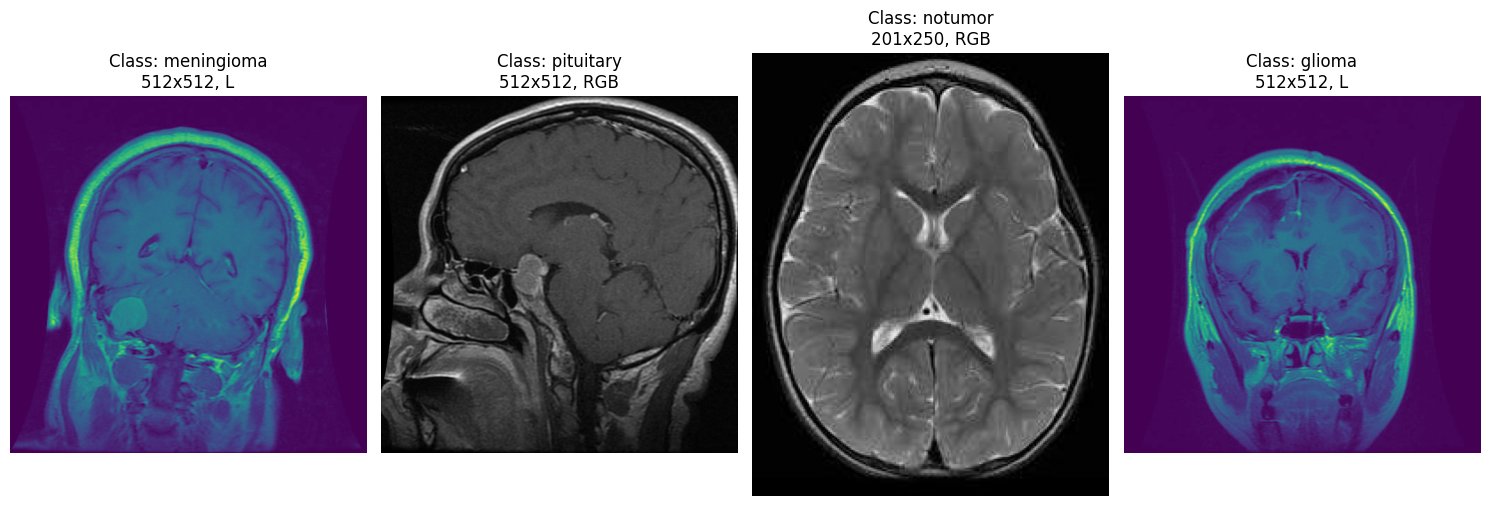

In [ ]:
def inspect_and_display_samples(base_path, classes):
    plt.figure(figsize=(15, 10))

    for i, class_name in enumerate(classes):
        class_path = os.path.join(base_path, class_name)
        image_name = random.choice(os.listdir(class_path))
        image_path = os.path.join(class_path, image_name)

        with Image.open(image_path) as img:
            width, height = img.size
            mode = img.mode  # RGB, L (grayscale), etc.
            format = img.format

            # Display sample
            plt.subplot(1, 4, i + 1)
            plt.imshow(img)
            plt.title(f"Class: {class_name}\n{width}x{height}, {mode}")
            plt.axis('off')

            print(f"Sample from {class_name}: {width}x{height}, Mode: {mode}, Format: {format}")

    plt.tight_layout()
    plt.show()

inspect_and_display_samples(dataset_path, list(training_stats.keys()))

# Initial Visualization

/tmp/ipython-input-3572011005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=names, y=counts, palette='viridis')


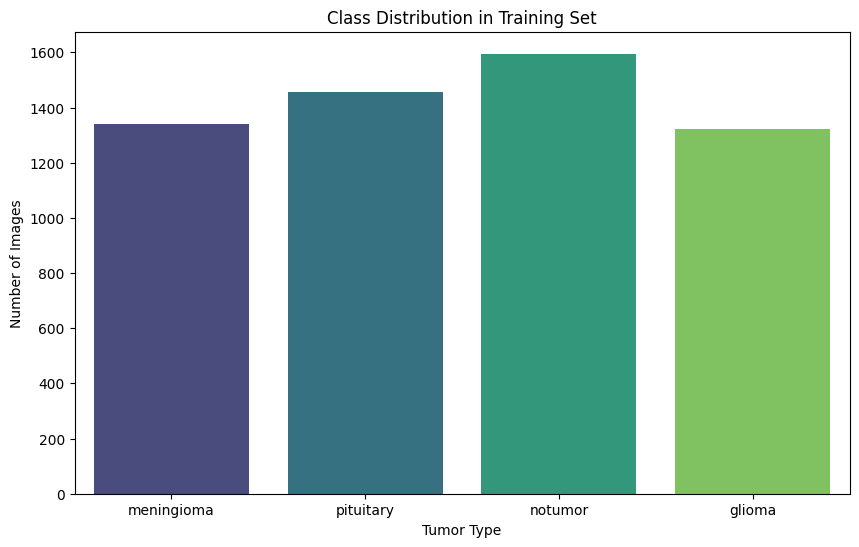

In [ ]:
def plot_distribution(stats):
    names = list(stats.keys())
    counts = list(stats.values())

    plt.figure(figsize=(10, 6))
    sns.barplot(x=names, y=counts, palette='viridis')
    plt.title('Class Distribution in Training Set')
    plt.xlabel('Tumor Type')
    plt.ylabel('Number of Images')
    plt.show()

plot_distribution(training_stats)

# Image Formats

In [ ]:
def verify_images(base_path):
    corrupted_files = []
    supported_formats = ('.jpg', '.jpeg', '.png', '.bmp')

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if not file.lower().endswith(supported_formats):
                print(f"Non-image file found: {os.path.join(root, file)}")
                continue

            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.verify()  # Verify it's a valid image
            except (IOError, SyntaxError) as e:
                print(f"Corrupted file: {file_path}")
                corrupted_files.append(file_path)

    if not corrupted_files:
        print("All images verified successfully!")
    else:
        print(f"Found {len(corrupted_files)} corrupted files.")
    return corrupted_files

corrupted = verify_images(dataset_path)

All images verified successfully!


# Avg Dimensions

Analyzing all images... this may take a moment.

--- Dimension Statistics ---
Mean Width: 451.563200280112
Mean Height: 453.8837535014006
Median Width: 512.0
Median Height: 512.0
Min Width: 150
Max Width: 1920
Mode Counts: {'RGB': 3236, 'L': 2472, 'RGBA': 3, 'P': 1}


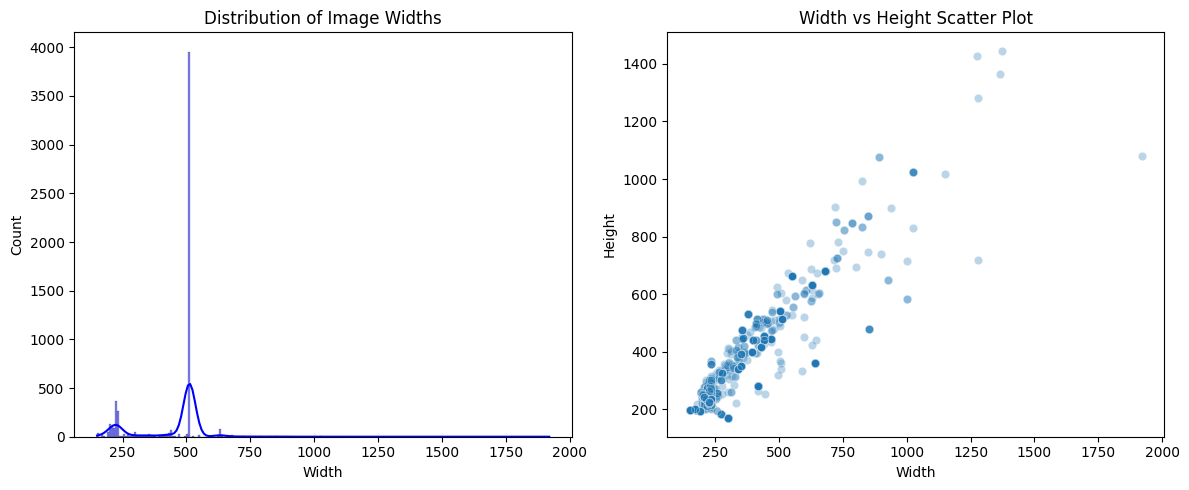

In [ ]:
def analyze_dimensions(base_path):
    widths = []
    heights = []
    modes = []

    print("Analyzing all images... this may take a moment.")

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        w, h = img.size
                        widths.append(w)
                        heights.append(h)
                        modes.append(img.mode)
                except Exception as e:
                    continue

    # DataFrame for easy analysis
    df = pd.DataFrame({'Width': widths, 'Height': heights, 'Mode': modes})

    # Statistics
    stats = {
        'Mean Width': df['Width'].mean(),
        'Mean Height': df['Height'].mean(),
        'Median Width': df['Width'].median(),
        'Median Height': df['Height'].median(),
        'Min Width': df['Width'].min(),
        'Max Width': df['Width'].max(),
        'Mode Counts': df['Mode'].value_counts().to_dict()
    }

    print("\n--- Dimension Statistics ---")
    for key, value in stats.items():
        print(f"{key}: {value}")

    # Visualization
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df['Width'], kde=True, color='blue')
    plt.title('Distribution of Image Widths')

    plt.subplot(1, 2, 2)
    sns.scatterplot(x='Width', y='Height', data=df, alpha=0.3)
    plt.title('Width vs Height Scatter Plot')

    plt.tight_layout()
    plt.show()

    return df

# Run the analysis
dim_df = analyze_dimensions(dataset_path)

# Preprocessing Pipeline Functions

In [ ]:
def crop_brain_contour(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # reduce noise
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Threshold 45
    _, thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)

    # erosions and dilations
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Find contours
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]

    if not cnts:
        return image

    c = max(cnts, key=cv2.contourArea)

    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    return new_image

In [ ]:
def preprocess_image(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path)
    if img is None:
        return None

    img = crop_brain_contour(img)

    # Resize
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_CUBIC)

    # Normalization
    img = img.astype('float32') / 255.0

    return img

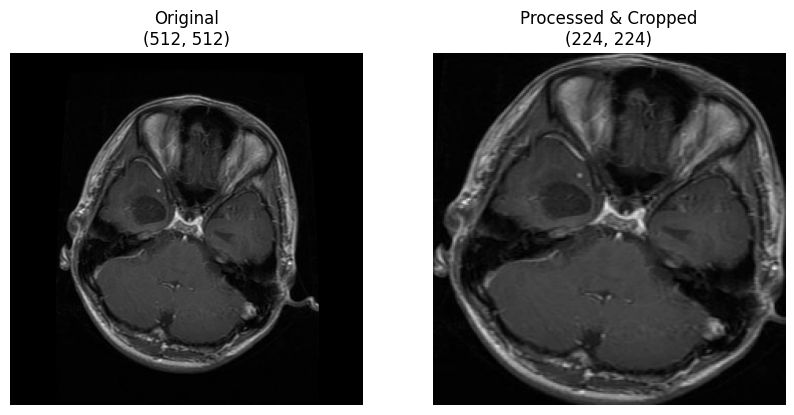

In [ ]:
def show_preprocessing_effect(image_path):
    original = cv2.imread(image_path)
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # Apply pipeline
    processed = preprocess_image(image_path)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title(f"Original\n{original.shape[:2]}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(processed)
    plt.title(f"Processed & Cropped\n{processed.shape[:2]}")
    plt.axis('off')
    plt.show()

# Test 1 image
sample_path = os.path.join(dataset_path, 'glioma', os.listdir(os.path.join(dataset_path, 'glioma'))[0])
show_preprocessing_effect(sample_path)

# Cleanup Duplicates

In [ ]:
def professional_cleanup_raw(raw_train_path, raw_test_path):
    hashes = {}
    to_delete = []

    print(f"Mapping fingerprints from: {raw_test_path}")
    for root, dirs, files in os.walk(raw_test_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                path = os.path.join(root, file)
                with open(path, 'rb') as f:
                    f_hash = hashlib.md5(f.read()).hexdigest()
                hashes[f_hash] = "TEST_SET"

    print(f"Scanning fingerprints in: {raw_train_path}")
    for root, dirs, files in os.walk(raw_train_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                path = os.path.join(root, file)
                with open(path, 'rb') as f:
                    f_hash = hashlib.md5(f.read()).hexdigest()

                if f_hash in hashes:
                    to_delete.append(path)
                else:
                    hashes[f_hash] = path

    print(f"\nCleanup Plan: Found {len(to_delete)} images to remove from Training.")

    for path in to_delete:
        if os.path.exists(path):
            os.remove(path)

    print("Cleanup Complete.")

professional_cleanup_raw('/content/Training', '/content/Testing')

Mapping fingerprints from: /content/Testing
Scanning fingerprints in: /content/Training

Cleanup Plan: Found 270 images to remove from Training.
Cleanup Complete.


# Pre-process and Save

In [ ]:
def process_and_save_dataset(source_dir, target_dir, target_size=(224, 224)):
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

    for class_name in classes:
        print(f"Processing class: {class_name}")
        source_class_path = os.path.join(source_dir, class_name)
        target_class_path = os.path.join(target_dir, class_name)

        if not os.path.exists(target_class_path):
            os.makedirs(target_class_path)
        # Pipeline
        for img_name in tqdm(os.listdir(source_class_path)):
            source_img_path = os.path.join(source_class_path, img_name)

            img = cv2.imread(source_img_path)
            if img is not None:
                img = crop_brain_contour(img)
                img = cv2.resize(img, target_size, interpolation=cv2.INTER_CUBIC)

                target_img_path = os.path.join(target_class_path, img_name)
                cv2.imwrite(target_img_path, img)

cleaned_dataset_path = '/content/brain_tumor_cleaned'
process_and_save_dataset(dataset_path, cleaned_dataset_path)

Processing class: notumor


100%|██████████| 1350/1350 [00:03<00:00, 442.22it/s]


Processing class: meningioma


100%|██████████| 1331/1331 [00:04<00:00, 331.38it/s]


Processing class: glioma


100%|██████████| 1321/1321 [00:04<00:00, 291.40it/s]


Processing class: pituitary


100%|██████████| 1440/1440 [00:04<00:00, 311.34it/s]


# Split

In [ ]:
input_folder = '/content/brain_tumor_cleaned'
output_folder = '/content/brain_tumor_final_split'

# 80% Train, 10% Val, 10% Test
splitfolders.ratio(input_folder, output=output_folder,
                   seed=42, ratio=(.8, .1, .1),
                   group_prefix=None, move=False)

def verify_split(base_path):
    for split in ['train', 'val', 'test']:
        print(f"--- {split.upper()} SET ---")
        split_path = os.path.join(base_path, split)
        for class_name in os.listdir(split_path):
            count = len(os.listdir(os.path.join(split_path, class_name)))
            print(f"{class_name}: {count} images")

verify_split(output_folder)

Copying files: 5442 files [00:00, 6489.88 files/s]

--- TRAIN SET ---
notumor: 1080 images
meningioma: 1064 images
glioma: 1056 images
pituitary: 1152 images
--- VAL SET ---
notumor: 135 images
meningioma: 133 images
glioma: 132 images
pituitary: 144 images
--- TEST SET ---
notumor: 135 images
meningioma: 134 images
glioma: 133 images
pituitary: 144 images


# Data Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalization
    rotation_range=15,         # rotate
    width_shift_range=0.1,     # shift horizontally
    height_shift_range=0.1,    # shift vertically
    horizontal_flip=True,      # Flip images
    zoom_range=0.1             # zoom in/out
)

# For Validation and Test ONLY rescale (No augmentation!)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Generators
batch_size = 32
target_size = (224, 224)
final_base_path = '/content/brain_tumor_final_split'

train_generator = train_datagen.flow_from_directory(
    os.path.join(final_base_path, 'train'),
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(final_base_path, 'val'),
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(final_base_path, 'test'),
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 4352 images belonging to 4 classes.
Found 544 images belonging to 4 classes.
Found 546 images belonging to 4 classes.


# Custom CNN

## 1st CNN

In [ ]:
def build_simple_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential([
        # Feature Extraction
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Look for more complex shapes
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # The "Classifier" Head
        layers.Flatten(), # 2D features into a 1D vector
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

custom_model = build_simple_cnn()
custom_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,908 (91.20 MB)

 Trainable params: 23,907,908 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

## 2nd CNN

In [ ]:
# Adding "Depth" and "Regularization"
def build_phase2_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential([

        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Shrinks the image more
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # deeper features
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        # Dropout
        layers.Dropout(0.5),

        layers.Dense(512, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

model_v2 = build_phase2_cnn()
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,680,580 (36.93 MB)

 Trainable params: 9,680,580 (36.93 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# safety monitors
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [ ]:
# Start Training
history = model_v2.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 62s 394ms/step - accuracy: 0.4258 - loss: 1.2087 - val_accuracy: 0.6176 - val_loss: 0.9604 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 374ms/step - accuracy: 0.6581 - loss: 0.8208 - val_accuracy: 0.7096 - val_loss: 0.7216 - learning_rate: 0.0010
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 379ms/step - accuracy: 0.7010 - loss: 0.7476 - val_accuracy: 0.6857 - val_loss: 0.8511 - learning_rate: 0.0010
Epoch 4/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 372ms/step - accuracy: 0.7390 - loss: 0.6601 - val_accuracy: 0.8493 - val_loss: 0.4179 - learning_rate: 0.0010
Epoch 5/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 50s 370ms/step - accuracy: 0.7718 - loss: 0.5967 - val_accuracy: 0.8327 - val_loss: 0.4339 - learning_rate: 0.0010
Epoch 6/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 375ms/step - accuracy: 0.8108 - loss: 0.5038 - val_accuracy: 0.8199 - val_loss: 0.4706 - learning_rate: 0.0010
Epoch 7/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 50s 368ms/step - accuracy: 0.8

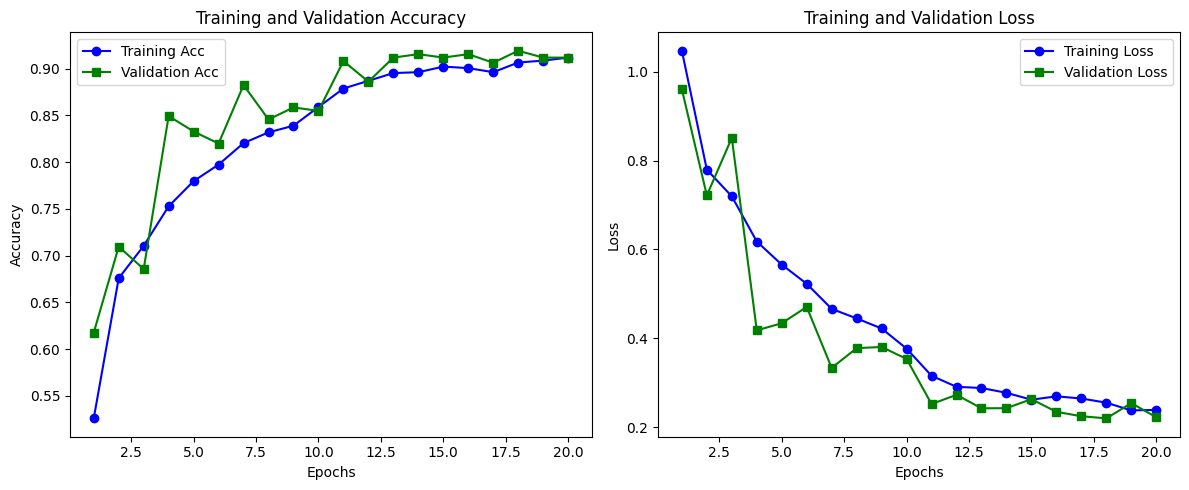

In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'gs-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'gs-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

## Evaluation

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.8846 - loss: 0.2921

Test Accuracy: 91.76%
Test Loss: 0.2074
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step


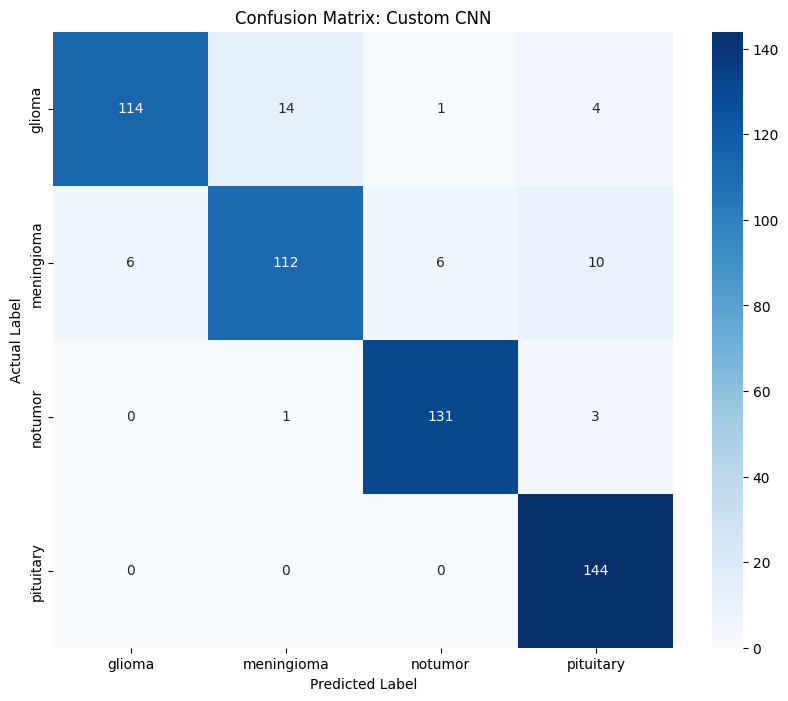


Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.86      0.90       133
  meningioma       0.88      0.84      0.86       134
     notumor       0.95      0.97      0.96       135
   pituitary       0.89      1.00      0.94       144

    accuracy                           0.92       546
   macro avg       0.92      0.92      0.92       546
weighted avg       0.92      0.92      0.92       546



In [ ]:
test_loss, test_acc = model_v2.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

test_generator.reset()
predictions = model_v2.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix: Custom CNN')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# MobileNetV2

In [ ]:
def build_transfer_learning_model(input_shape=(224, 224, 3), num_classes=4):
    # Load
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze base
    base_model.trainable = False

    # custom layers on top
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x) # Reduces the 7x7 features to a single vector
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    predictions = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

pro_model = build_transfer_learning_model()
pro_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# same callbacks
history_pro = pro_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 76s 411ms/step - accuracy: 0.6794 - loss: 0.8254 - val_accuracy: 0.8603 - val_loss: 0.3547 - learning_rate: 0.0010
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 50s 370ms/step - accuracy: 0.8342 - loss: 0.4318 - val_accuracy: 0.8107 - val_loss: 0.4693 - learning_rate: 0.0010
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 50s 368ms/step - accuracy: 0.8461 - loss: 0.4120 - val_accuracy: 0.8511 - val_loss: 0.4272 - learning_rate: 0.0010
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 375ms/step - accuracy: 0.8639 - loss: 0.3485 - val_accuracy: 0.8511 - val_loss: 0.3931 - learning_rate: 0.0010
Epoch 5/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 373ms/step - accuracy: 0.8871 - loss: 0.3182 - val_accuracy: 0.8897 - val_loss: 0.3057 - learning_rate: 2.0000e-04
Epoch 6/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 52s 380ms/step - accuracy: 0.8775 - loss: 0.3073 - val_accuracy: 0.8897 - val_loss: 0.3076 - learning_rate: 2.0000e-04
Epoch 7/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 372ms/step - accur

## Fine-Tuning

In [ ]:
# Unfreeze base model
pro_model.trainable = True

# smaller learning rate
pro_model.compile(optimizer=Adam(1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_fine = pro_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 64s 396ms/step - accuracy: 0.9001 - loss: 0.2488 - val_accuracy: 0.9118 - val_loss: 0.2456 - learning_rate: 1.0000e-05
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 371ms/step - accuracy: 0.9030 - loss: 0.2517 - val_accuracy: 0.9154 - val_loss: 0.2428 - learning_rate: 1.0000e-05
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 373ms/step - accuracy: 0.9129 - loss: 0.2331 - val_accuracy: 0.9173 - val_loss: 0.2400 - learning_rate: 1.0000e-05
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 375ms/step - accuracy: 0.8948 - loss: 0.2655 - val_accuracy: 0.9173 - val_loss: 0.2394 - learning_rate: 1.0000e-05
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 371ms/step - accuracy: 0.9110 - loss: 0.2316 - val_accuracy: 0.9118 - val_loss: 0.2448 - learning_rate: 1.0000e-05
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 373ms/step - accuracy: 0.8990 - loss: 0.2554 - val_accuracy: 0.9154 - val_loss: 0.2424 - learning_rate: 1.0000e-05
Epoch 7/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 50s 37

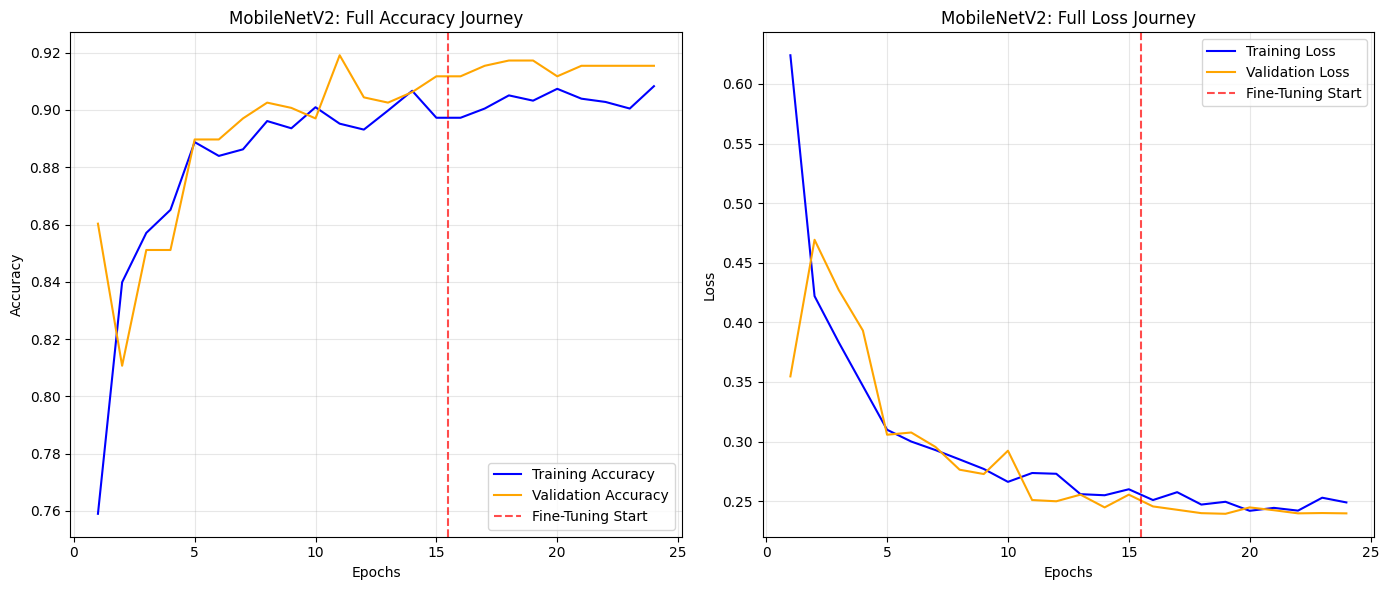

In [ ]:
def plot_full_mobilenet_history(h1, h2):
    # Combine
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs = range(1, len(acc) + 1)
    fine_tune_start = len(h1.history['accuracy'])

    plt.figure(figsize=(14, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs, val_acc, label='Validation Accuracy', color='orange')
    plt.axvline(x=fine_tune_start + 0.5, color='red', linestyle='--',
                label='Fine-Tuning Start', alpha=0.7)
    plt.title('MobileNetV2: Full Accuracy Journey')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss', color='blue')
    plt.plot(epochs, val_loss, label='Validation Loss', color='orange')
    plt.axvline(x=fine_tune_start + 0.5, color='red', linestyle='--',
                label='Fine-Tuning Start', alpha=0.7)
    plt.title('MobileNetV2: Full Loss Journey')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_full_mobilenet_history(history_pro, history_fine)

## Test Set Evaluation

Evaluating MobileNetV2 on Test Set...
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 610ms/step - accuracy: 0.8871 - loss: 0.3035

MobileNetV2 Test Accuracy: 90.29%
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 291ms/step


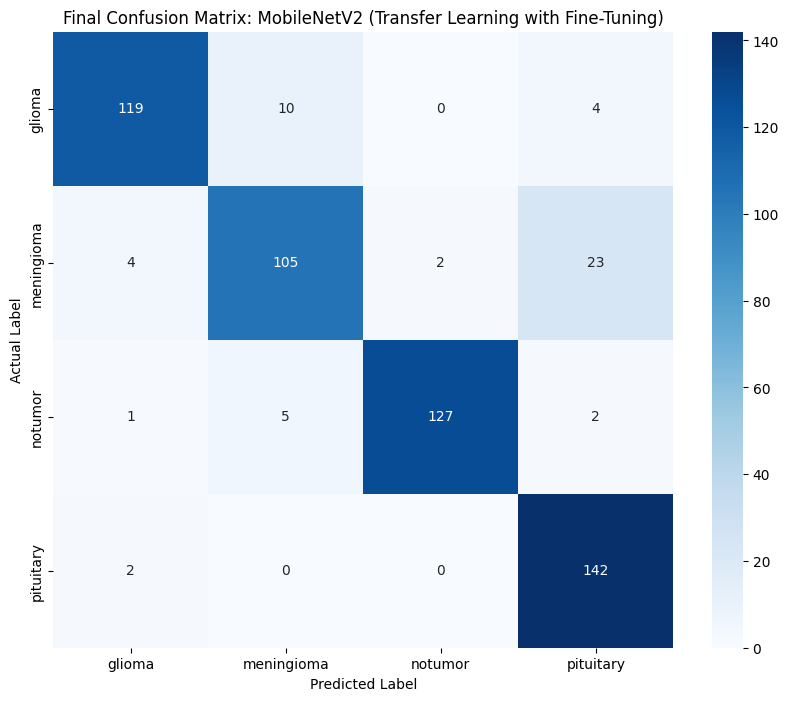


MobileNetV2 Final Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.89      0.92       133
  meningioma       0.88      0.78      0.83       134
     notumor       0.98      0.94      0.96       135
   pituitary       0.83      0.99      0.90       144

    accuracy                           0.90       546
   macro avg       0.91      0.90      0.90       546
weighted avg       0.91      0.90      0.90       546



In [ ]:
print("Evaluating MobileNetV2 on Test Set...")
pro_test_loss, pro_test_acc = pro_model.evaluate(test_generator)
print(f"\nMobileNetV2 Test Accuracy: {pro_test_acc*100:.2f}%")

test_generator.reset()
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Predictions
pro_preds = pro_model.predict(test_generator)
pro_y_pred = np.argmax(pro_preds, axis=1)

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_pro = confusion_matrix(y_true, pro_y_pred)
sns.heatmap(cm_pro, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Final Confusion Matrix: MobileNetV2 (Transfer Learning with Fine-Tuning)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nMobileNetV2 Final Classification Report:")
print(classification_report(y_true, pro_y_pred, target_names=class_labels))

# ResNet50V2

In [ ]:
def build_resnet_model(input_shape=(224, 224, 3), num_classes=4):
    # Load
    base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze
    base_model.trainable = False

    # head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x) # Added for stability
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    predictions = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

resnet_model = build_resnet_model()
resnet_model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,098,564 (91.93 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

In [ ]:
# Build the model
resnet_model = build_resnet_model()

# Train
print("Starting ResNet50V2 Training (Frozen Base)...")
history_resnet = resnet_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

Starting ResNet50V2 Training (Frozen Base)...
Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 72s 435ms/step - accuracy: 0.7345 - loss: 0.7795 - val_accuracy: 0.8860 - val_loss: 0.3266 - learning_rate: 0.0010
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 52s 384ms/step - accuracy: 0.8764 - loss: 0.3578 - val_accuracy: 0.9173 - val_loss: 0.2158 - learning_rate: 0.0010
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 54s 395ms/step - accuracy: 0.8935 - loss: 0.2983 - val_accuracy: 0.9338 - val_loss: 0.2020 - learning_rate: 0.0010
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 54s 395ms/step - accuracy: 0.9206 - loss: 0.2255 - val_accuracy: 0.9265 - val_loss: 0.1925 - learning_rate: 0.0010
Epoch 5/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 52s 386ms/step - accuracy: 0.9126 - loss: 0.2232 - val_accuracy: 0.9449 - val_loss: 0.1658 - learning_rate: 0.0010
Epoch 6/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 52s 384ms/step - accuracy: 0.9281 - loss: 0.1890 - val_accuracy: 0.9320 - val_loss: 0.1769 - learning_rate: 0.0010
Epoch 7/15
136/136 ━━━━━

## Fine-Tuning (Unfrozen Base)

In [ ]:
resnet_model.trainable = True

# Re-compile
resnet_model.compile(optimizer=Adam(1e-5),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Fine-tune
print("Starting ResNet50V2 Fine-Tuning...")
history_resnet_fine = resnet_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

Starting ResNet50V2 Fine-Tuning...
Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 69s 434ms/step - accuracy: 0.9600 - loss: 0.1004 - val_accuracy: 0.9559 - val_loss: 0.1331 - learning_rate: 1.0000e-05
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 53s 390ms/step - accuracy: 0.9681 - loss: 0.0987 - val_accuracy: 0.9577 - val_loss: 0.1325 - learning_rate: 1.0000e-05
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 55s 399ms/step - accuracy: 0.9541 - loss: 0.1137 - val_accuracy: 0.9559 - val_loss: 0.1320 - learning_rate: 1.0000e-05
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 53s 389ms/step - accuracy: 0.9738 - loss: 0.0872 - val_accuracy: 0.9559 - val_loss: 0.1317 - learning_rate: 1.0000e-05
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 54s 398ms/step - accuracy: 0.9600 - loss: 0.1106 - val_accuracy: 0.9577 - val_loss: 0.1332 - learning_rate: 1.0000e-05
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 53s 388ms/step - accuracy: 0.9612 - loss: 0.1034 - val_accuracy: 0.9577 - val_loss: 0.1340 - learning_rate: 1.0000e-05
Epoch 7/10


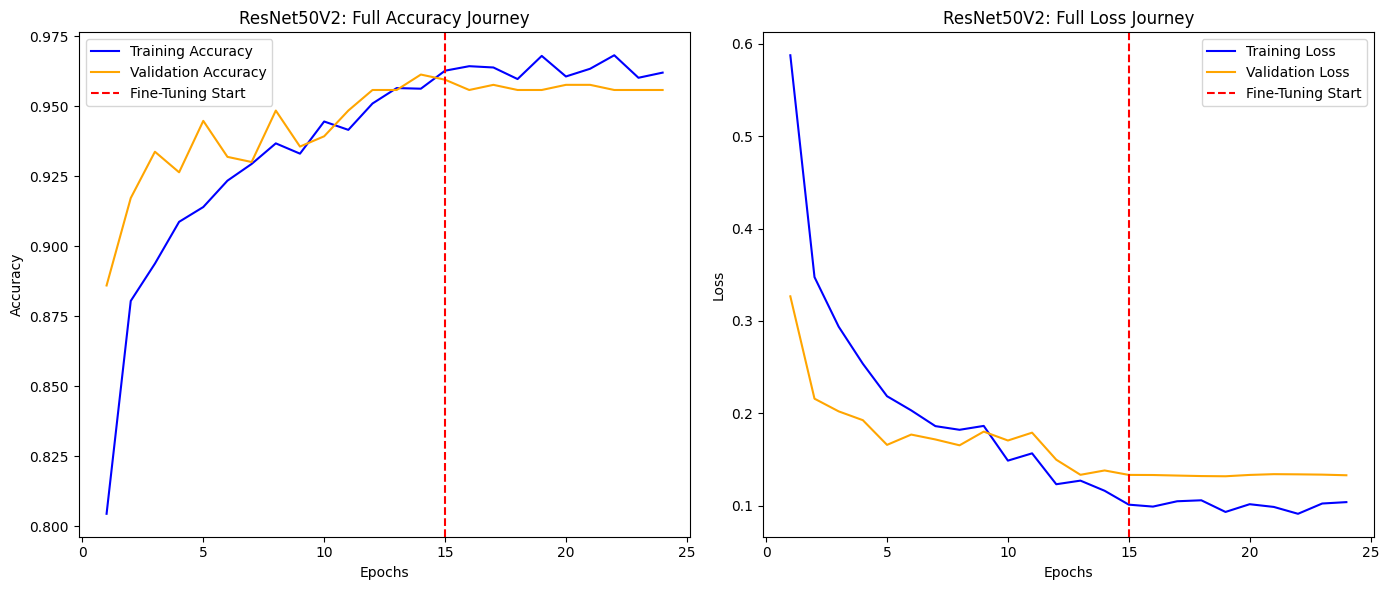

In [ ]:
def plot_full_resnet_history(h1, h2):
    # Combine
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs = range(1, len(acc) + 1)
    fine_tune_start = len(h1.history['accuracy'])

    plt.figure(figsize=(14, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs, val_acc, label='Validation Accuracy', color='orange')
    plt.axvline(x=fine_tune_start, color='red', linestyle='--', label='Fine-Tuning Start')
    plt.title('ResNet50V2: Full Accuracy Journey')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss', color='blue')
    plt.plot(epochs, val_loss, label='Validation Loss', color='orange')
    plt.axvline(x=fine_tune_start, color='red', linestyle='--', label='Fine-Tuning Start')
    plt.title('ResNet50V2: Full Loss Journey')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_full_resnet_history(history_resnet, history_resnet_fine)

## Evaluate

Evaluating ResNet50V2 on Test Set...
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 271ms/step - accuracy: 0.9515 - loss: 0.1337

ResNet50V2 Test Accuracy: 95.24%
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 261ms/step


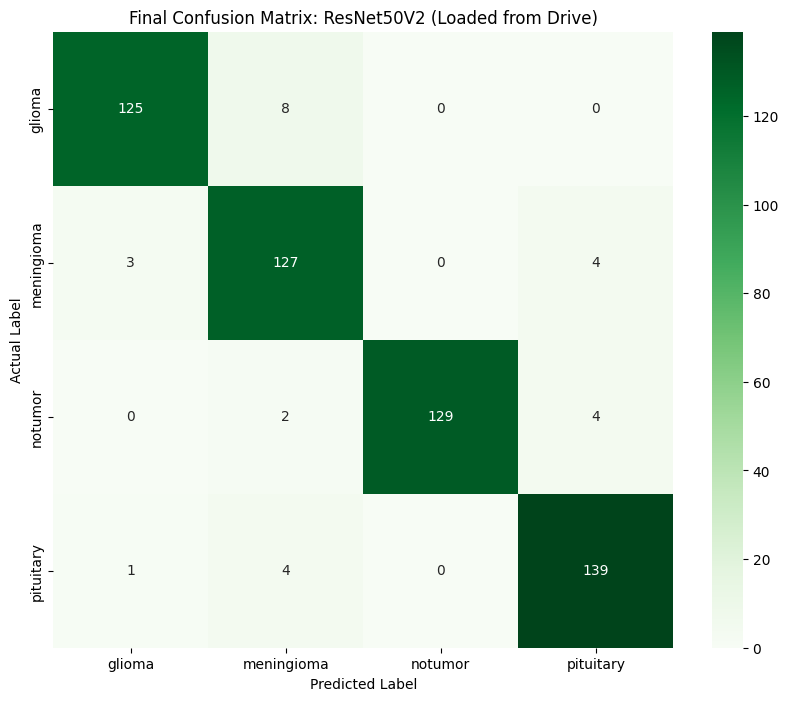


ResNet50V2 Final Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.94      0.95       133
  meningioma       0.90      0.95      0.92       134
     notumor       1.00      0.96      0.98       135
   pituitary       0.95      0.97      0.96       144

    accuracy                           0.95       546
   macro avg       0.95      0.95      0.95       546
weighted avg       0.95      0.95      0.95       546



In [ ]:
test_generator.reset()
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Evaluating ResNet50V2 on Test Set...")
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(test_generator)
print(f"\nResNet50V2 Test Accuracy: {resnet_test_acc*100:.2f}%")

# Predictions
test_generator.reset()
resnet_preds = resnet_model.predict(test_generator)
resnet_y_pred = np.argmax(resnet_preds, axis=1)

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_resnet = confusion_matrix(y_true, resnet_y_pred)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Final Confusion Matrix: ResNet50V2 (Loaded from Drive)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nResNet50V2 Final Classification Report:")
print(classification_report(y_true, resnet_y_pred, target_names=class_labels))

# EfficientNetB0

In [ ]:
def build_efficientnet_model(input_shape=(224, 224, 3), num_classes=4):
    # Load
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze
    base_model.trainable = False

    # head
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    predictions = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

eff_model = build_efficientnet_model()
# eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Frozen Base
print("Starting EfficientNetB0 Training (Frozen Base)...")
history_eff = eff_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

# Fine-Tuning
eff_model.trainable = True
eff_model.compile(optimizer=Adam(1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("Starting EfficientNetB0 Fine-Tuning...")
history_eff_fine = eff_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

Starting EfficientNetB0 Training (Frozen Base)...
Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 83s 426ms/step - accuracy: 0.2979 - loss: 1.7180 - val_accuracy: 0.2482 - val_loss: 1.3659 - learning_rate: 0.0010
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 52s 380ms/step - accuracy: 0.3360 - loss: 1.5023 - val_accuracy: 0.2482 - val_loss: 1.3586 - learning_rate: 0.0010
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 374ms/step - accuracy: 0.3435 - loss: 1.4210 - val_accuracy: 0.4301 - val_loss: 1.3436 - learning_rate: 0.0010
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 374ms/step - accuracy: 0.3565 - loss: 1.3406 - val_accuracy: 0.3934 - val_loss: 1.3135 - learning_rate: 0.0010
Epoch 5/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 51s 375ms/step - accuracy: 0.3498 - loss: 1.3239 - val_accuracy: 0.4283 - val_loss: 1.2814 - learning_rate: 0.0010
Epoch 6/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 52s 379ms/step - accuracy: 0.3456 - loss: 1.3132 - val_accuracy: 0.4026 - val_loss: 1.2434 - learning_rate: 0.0010
Epoch 7/15
136/136 ━

## evaluation for the EfficientNetB0

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 513ms/step - accuracy: 0.2457 - loss: 1.2649

EfficientNetB0 Test Accuracy: 44.69%
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 433ms/step


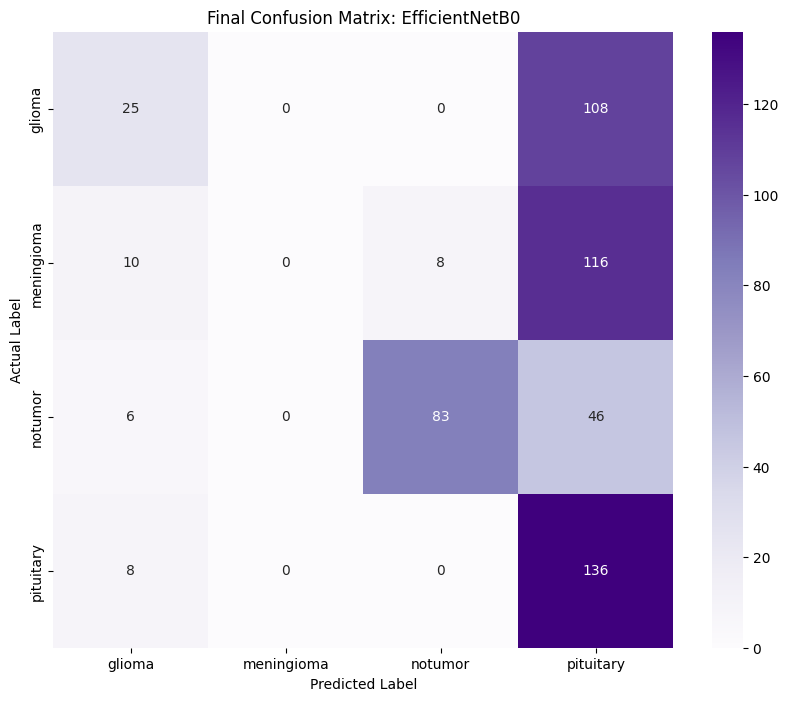


EfficientNetB0 Final Classification Report:
              precision    recall  f1-score   support

      glioma       0.51      0.19      0.27       133
  meningioma       0.00      0.00      0.00       134
     notumor       0.91      0.61      0.73       135
   pituitary       0.33      0.94      0.49       144

    accuracy                           0.45       546
   macro avg       0.44      0.44      0.38       546
weighted avg       0.44      0.45      0.38       546



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
eff_test_loss, eff_test_acc = eff_model.evaluate(test_generator)
print(f"\nEfficientNetB0 Test Accuracy: {eff_test_acc*100:.2f}%")

# Confusion Matrix
test_generator.reset()
eff_preds = eff_model.predict(test_generator)
eff_y_pred = np.argmax(eff_preds, axis=1)

plt.figure(figsize=(10, 8))
cm_eff = confusion_matrix(y_true, eff_y_pred)
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Final Confusion Matrix: EfficientNetB0')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nEfficientNetB0 Final Classification Report:")
print(classification_report(y_true, eff_y_pred, target_names=class_labels))

# Compare Models


--- Final Project Comparison ---
            Model  Test Accuracy (%)
0      Custom CNN          92.000000
1     MobileNetV2          90.480000
2      ResNet50V2          95.000000
3  EfficientNetB0          44.688645


/tmp/ipython-input-297515815.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test Accuracy (%)', data=df_results, palette='magma')


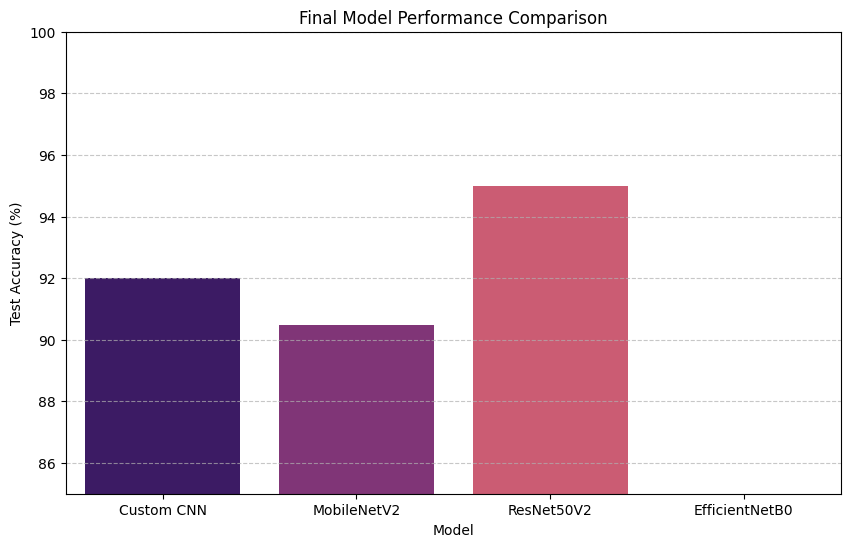

In [ ]:
results = {
    'Model': ['Custom CNN', 'MobileNetV2', 'ResNet50V2', 'EfficientNetB0'],
    'Test Accuracy (%)': [92.00, 90.48, 95.00, eff_test_acc*100]
}

df_results = pd.DataFrame(results)
print("\n--- Final Project Comparison ---")
print(df_results)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Test Accuracy (%)', data=df_results, palette='magma')
plt.ylim(85, 100)
plt.title('Final Model Performance Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Final Train (Best Model)

## Re-organizing and Splitting the Data

In [ ]:
cleaned_input = '/content/brain_tumor_cleaned'
new_split_output = '/content/brain_tumor_pro_split'

# 90% Train, 10% Val, 0% Test
splitfolders.ratio(cleaned_input, output=new_split_output,
                   seed=42, ratio=(.9, .1),
                   group_prefix=None, move=False)

def verify_new_split(base_path):
    for split in ['train', 'val']:
        print(f"--- {split.upper()} SET ---")
        split_path = os.path.join(base_path, split)
        for class_name in os.listdir(split_path):
            count = len(os.listdir(os.path.join(split_path, class_name)))
            print(f"{class_name}: {count} images")

verify_new_split(new_split_output)

Copying files: 5442 files [00:00, 6405.55 files/s]

--- TRAIN SET ---
notumor: 1215 images
meningioma: 1197 images
glioma: 1188 images
pituitary: 1296 images
--- VAL SET ---
notumor: 135 images
meningioma: 134 images
glioma: 133 images
pituitary: 144 images


## Preprocessing Test Folder

In [ ]:
kaggle_test_raw = '/content/Testing'
kaggle_test_cleaned = '/content/brain_tumor_test_cleaned'

print("Preprocessing the Kaggle Test folder...")
process_and_save_dataset(kaggle_test_raw, kaggle_test_cleaned)

# Verify
print("\n--- KAGGLE TEST SET (CLEANED) ---")
for class_name in os.listdir(kaggle_test_cleaned):
    count = len(os.listdir(os.path.join(kaggle_test_cleaned, class_name)))
    print(f"{class_name}: {count} images")

Preprocessing the Kaggle Test folder...
Processing class: notumor


100%|██████████| 405/405 [00:00<00:00, 570.51it/s]


Processing class: meningioma


100%|██████████| 306/306 [00:00<00:00, 394.53it/s]


Processing class: glioma


100%|██████████| 300/300 [00:00<00:00, 363.87it/s]


Processing class: pituitary


100%|██████████| 300/300 [00:00<00:00, 332.90it/s]


--- KAGGLE TEST SET (CLEANED) ---
notumor: 405 images
meningioma: 306 images
glioma: 300 images
pituitary: 300 images


## The New Data Generators

In [ ]:
# Generators
train_generator_pro = train_datagen.flow_from_directory(
    os.path.join(new_split_output, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator_pro = val_test_datagen.flow_from_directory(
    os.path.join(new_split_output, 'val'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Test Generator
test_generator_kaggle = val_test_datagen.flow_from_directory(
    kaggle_test_cleaned,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 4896 images belonging to 4 classes.
Found 546 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


## Re-training ResNet50V2 with the New Split

In [ ]:
def build_resnet_pro(input_shape=(224, 224, 3), num_classes=4):
    base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False # Start frozen

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    predictions = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

resnet_pro = build_resnet_pro()

# callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Training Head (Frozen)
print("--- Phase 1: Training Frozen Base ---")
history_frozen = resnet_pro.fit(
    train_generator_pro,
    epochs=12,
    validation_data=val_generator_pro,
    callbacks=[early_stop, reduce_lr]
)

# Fine-Tuning (Unfrozen)
resnet_pro.trainable = True
resnet_pro.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

print("\n--- Phase 2: Fine-Tuning Unfrozen Base ---")
history_fine = resnet_pro.fit(
    train_generator_pro,
    epochs=10,
    validation_data=val_generator_pro,
    callbacks=[early_stop, reduce_lr]
)

--- Phase 1: Training Frozen Base ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
153/153 ━━━━━━━━━━━━━━━━━━━━ 85s 494ms/step - accuracy: 0.7644 - loss: 0.7349 - val_accuracy: 0.8956 - val_loss: 0.3133 - learning_rate: 0.0010
Epoch 2/12
153/153 ━━━━━━━━━━━━━━━━━━━━ 61s 397ms/step - accuracy: 0.8756 - loss: 0.3367 - val_accuracy: 0.9029 - val_loss: 0.2530 - learning_rate: 0.0010
Epoch 3/12
153/153 ━━━━━━━━━━━━━━━━━━━━ 61s 396ms/step - accuracy: 0.9087 - loss: 0.2602 - val_accuracy: 0.9176 - val_loss: 0.2418 - learning_rate: 0.0010
Epoch 4/12
153/153 ━━━━━━━━━━━━━━━━━━━━ 60s 395ms/step - accuracy: 0.9194 - loss: 0.2323 - val_accuracy: 0.9341 - val_loss: 0.2068 - learning_rate: 0.0010
Epoch 5/12
153/153 ━━━━━━━━━━━━━━━━━━━━ 59s 383ms/step - accuracy: 0.9247 - loss: 0.2031 - val_accuracy: 0.9432 - val_loss: 0.1840 - learning_rate: 0.0010
Epoch 6/12
153/153 ━━━━━━━━━━━━━━━━━━━━ 59s 385ms/step - accuracy: 0.9307 - loss: 0.1889 - val_accuracy: 0.9359 - val_loss: 0.1807 - learning_rate: 0.0010
Epoch 7/12
153/153 ━━━━━━━━━━━━━━━━━━━━ 60s 389ms/step - accuracy: 0.9

## Plotting

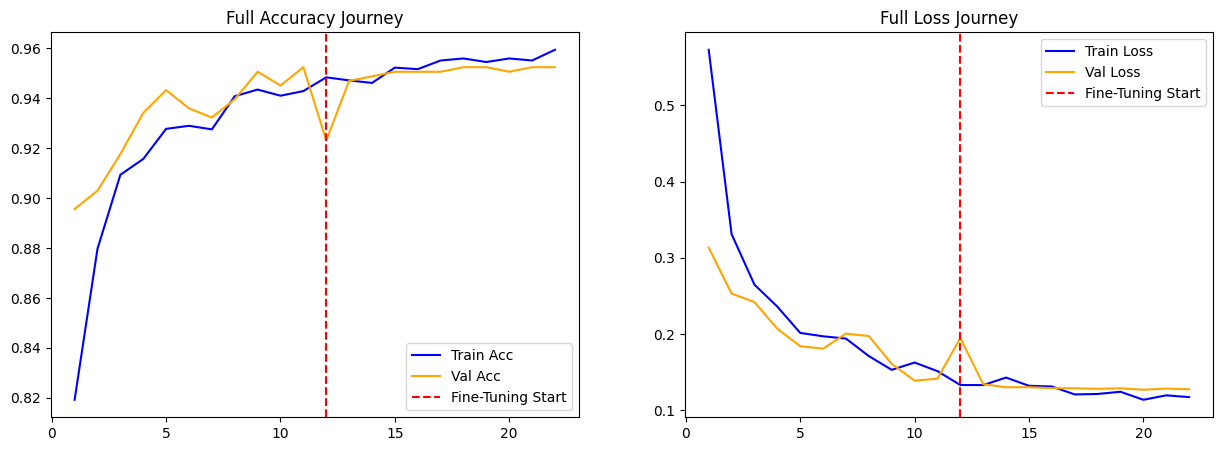

In [ ]:
def plot_final_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs = range(1, len(acc) + 1)
    split_point = len(h1.history['accuracy'])

    plt.figure(figsize=(15, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Acc', color='blue')
    plt.plot(epochs, val_acc, label='Val Acc', color='orange')
    plt.axvline(x=split_point, color='red', linestyle='--', label='Fine-Tuning Start')
    plt.title('Full Accuracy Journey')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss', color='blue')
    plt.plot(epochs, val_loss, label='Val Loss', color='orange')
    plt.axvline(x=split_point, color='red', linestyle='--', label='Fine-Tuning Start')
    plt.title('Full Loss Journey')
    plt.legend()

    plt.show()

plot_final_history(history_frozen, history_fine)

## Evaluation Test Set

Evaluating ResNet50V2 on Kaggle Test images...
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step - accuracy: 0.9313 - loss: 0.2126

Final Kaggle Test Accuracy: 94.36%
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step


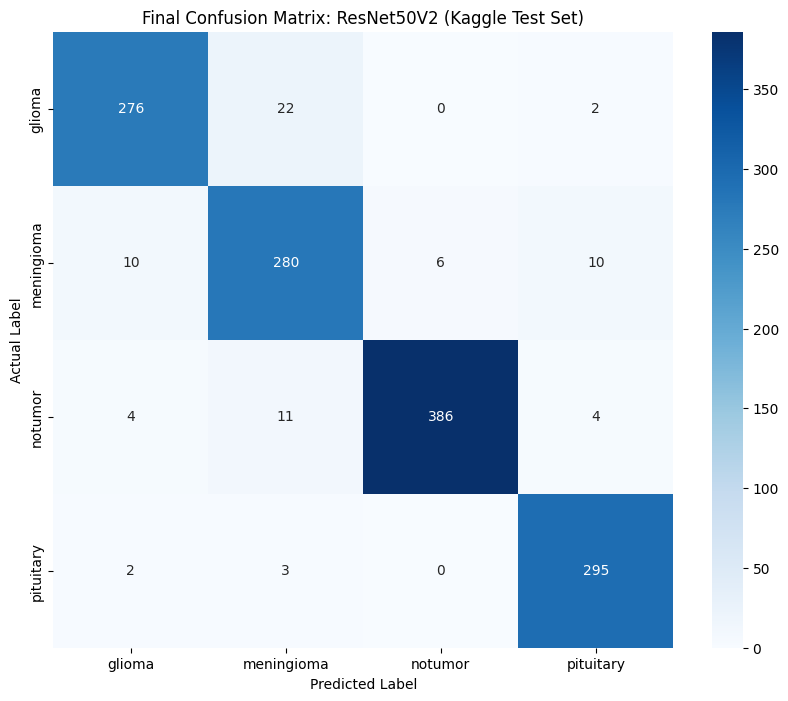


Final Classification Report:
              precision    recall  f1-score   support

      glioma       0.95      0.92      0.93       300
  meningioma       0.89      0.92      0.90       306
     notumor       0.98      0.95      0.97       405
   pituitary       0.95      0.98      0.97       300

    accuracy                           0.94      1311
   macro avg       0.94      0.94      0.94      1311
weighted avg       0.94      0.94      0.94      1311



In [ ]:
print("Evaluating ResNet50V2 on Kaggle Test images...")
final_test_loss, final_test_acc = resnet_pro.evaluate(test_generator_kaggle)
print(f"\nFinal Kaggle Test Accuracy: {final_test_acc*100:.2f}%")

# Predictions
test_generator_kaggle.reset()
final_preds = resnet_pro.predict(test_generator_kaggle)
final_y_pred = np.argmax(final_preds, axis=1)
final_y_true = test_generator_kaggle.classes
class_labels = list(test_generator_kaggle.class_indices.keys())

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_final = confusion_matrix(final_y_true, final_y_pred)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Final Confusion Matrix: ResNet50V2 (Kaggle Test Set)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nFinal Classification Report:")
print(classification_report(final_y_true, final_y_pred, target_names=class_labels))

## Save

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
flask_app_model_path = '/content/drive/MyDrive/Brain_Tumor_Project/flask_app_assets'

if not os.path.exists(flask_app_model_path):
    os.makedirs(flask_app_model_path)

model_filename = 'brain_tumor_resnet_v2.keras'
resnet_pro.save(os.path.join(flask_app_model_path, model_filename))

print(f"Success! Model saved at: {flask_app_model_path}/{model_filename}")

Success! Model saved at: /content/drive/MyDrive/Brain_Tumor_Project/flask_app_assets/brain_tumor_resnet_v2.keras


## Save the Class Names

In [ ]:
class_indices = train_generator_pro.class_indices
with open(os.path.join(flask_app_model_path, 'class_indices.json'), 'w') as f:
    json.dump(class_indices, f)

print("Class indices saved to class_indices.json")

Class indices saved to class_indices.json
